# Лабораторна робота №3
## Лінійна регресія та попередня обробка даних

**Дисципліна:** Методи інтелектуальної обробки даних  
**Виконав:** студент групи ІПС-41  
**Датасет:** [House Price Prediction – Kaggle](https://www.kaggle.com/datasets/shree1992/housedata)  
**Джерело даних:** ринок нерухомості штату Вашингтон, США (4600 об'єктів)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PowerTransformer
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_log_error,
    d2_absolute_error_score,
    r2_score
)

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11
sns.set_theme(style='whitegrid')
SEED = 42
print('Бібліотеки завантажено.')

Бібліотеки завантажено.


---
## Завдання 1. Підготовка набору даних

### 1.1 Завантаження набору даних

Датасет завантажено з Kaggle: **House Price Prediction** (housedata).  
Містить 4600 рядків і 18 стовпців. Цільова змінна – `price` (ціна будинку, USD).

In [2]:
df = pd.read_csv('data.csv')
print(f'Розмір датасету: {df.shape}')
df.head()

Розмір датасету: (4600, 18)


,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
0,2014-05-02 00:00:00,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,USA
1,2014-05-02 00:00:00,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,709 W Blaine St,Seattle,WA 98119,USA
2,2014-05-02 00:00:00,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent,WA 98042,USA
3,2014-05-02 00:00:00,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,857 170th Pl NE,Bellevue,WA 98008,USA
4,2014-05-02 00:00:00,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,9105 170th Ave NE,Redmond,WA 98052,USA


### 1.2 Базова підготовка даних

In [3]:
print('Типи даних:')
print(df.dtypes)
print()
print('Пропущені значення:')
print(df.isnull().sum())

Типи даних:
date                 str
price            float64
bedrooms         float64
bathrooms        float64
sqft_living        int64
sqft_lot           int64
floors           float64
waterfront         int64
view               int64
condition          int64
sqft_above         int64
sqft_basement      int64
yr_built           int64
yr_renovated       int64
street               str
city                 str
statezip             str
country              str
dtype: object

Пропущені значення:
date             0
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
street           0
city             0
statezip         0
country          0
dtype: int64


In [4]:
# Вибір числових ознак (виключаємо текстові колонки та дату)
FEATURES = [
    'bedrooms',
    'bathrooms',
    'sqft_living',
    'sqft_lot',
    'floors',
    'waterfront',
    'view',
    'condition',
    'sqft_above',
    'sqft_basement',
    'yr_built',
    'yr_renovated',
]
TARGET = 'price'

df_work = df[FEATURES + [TARGET]].copy()

# Корекція типів
for col in ['bedrooms', 'bathrooms', 'floors']:
    df_work[col] = df_work[col].astype(float)

print(f'Обрано {len(FEATURES)} ознак, цільова змінна: "{TARGET}"')
print(f'Рядків: {len(df_work)}')
df_work.describe()

Обрано 12 ознак, цільова змінна: "price"
Рядків: 4600


,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,price
count,4600.000000,4600.000000,4600.000000,4.600000e+03,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4.600000e+03
mean,3.400870,2.160815,2139.346957,1.485252e+04,1.512065,0.007174,0.240652,3.451739,1827.265435,312.081522,1970.786304,808.608261,5.519630e+05
std,0.908848,0.783781,963.206916,3.588444e+04,0.538288,0.084404,0.778405,0.677230,862.168977,464.137228,29.731848,979.414536,5.638347e+05
min,0.000000,0.000000,370.000000,6.380000e+02,1.000000,0.000000,0.000000,1.000000,370.000000,0.000000,1900.000000,0.000000,0.000000e+00
25%,3.000000,1.750000,1460.000000,5.000750e+03,1.000000,0.000000,0.000000,3.000000,1190.000000,0.000000,1951.000000,0.000000,3.228750e+05
50%,3.000000,2.250000,1980.000000,7.683000e+03,1.500000,0.000000,0.000000,3.000000,1590.000000,0.000000,1976.000000,0.000000,4.609435e+05
75%,4.000000,2.500000,2620.000000,1.100125e+04,2.000000,0.000000,0.000000,4.000000,2300.000000,610.000000,1997.000000,1999.000000,6.549625e+05
max,9.000000,8.000000,13540.000000,1.074218e+06,3.500000,1.000000,4.000000,5.000000,9410.000000,4820.000000,2014.000000,2014.000000,2.659000e+07


In [5]:
# Перевірка пропусків у вибраних колонках
missing = df_work.isnull().sum()
print('Пропущені значення після вибору ознак:')
print(missing[missing > 0] if missing.any() else 'Пропусків немає ✓')

Пропущені значення після вибору ознак:
Пропусків немає ✓


In [6]:
# Фільтрація аномалій методом IQR (k=1.5) по кожній колонці
def remove_outliers_iqr(data, columns, k=1.5):
    mask = pd.Series(True, index=data.index)
    for col in columns:
        Q1 = data[col].quantile(0.25)
        Q3 = data[col].quantile(0.75)
        IQR = Q3 - Q1
        mask &= data[col].between(Q1 - k * IQR, Q3 + k * IQR)
    return data[mask].reset_index(drop=True)

df_clean = remove_outliers_iqr(df_work, FEATURES + [TARGET])
print(f'Рядків до  фільтрації: {len(df_work)}')
print(f'Рядків після фільтрації: {len(df_clean)}')
print(f'Видалено аномалій: {len(df_work) - len(df_clean)} ({(len(df_work)-len(df_clean))/len(df_work)*100:.1f}%)')

Рядків до  фільтрації: 4600
Рядків після фільтрації: 3448
Видалено аномалій: 1152 (25.0%)


### 1.3 Знаходження залежностей

In [7]:
# Кореляційна матриця
corr_matrix = df_clean.corr(numeric_only=True)

# Ознаки відсортовані за абсолютною кореляцією з target
target_corr = corr_matrix[TARGET].drop(TARGET).abs().sort_values(ascending=False)
print('Ознаки за силою кореляції з price:')
print(target_corr.to_string())

Ознаки за силою кореляції з price:


sqft_living      0.562198
sqft_above       0.471605
bathrooms        0.399069
floors           0.272045
bedrooms         0.250875
sqft_basement    0.167011
yr_renovated     0.090649
condition        0.049921
sqft_lot         0.036027
yr_built         0.022591
waterfront            NaN
view                  NaN


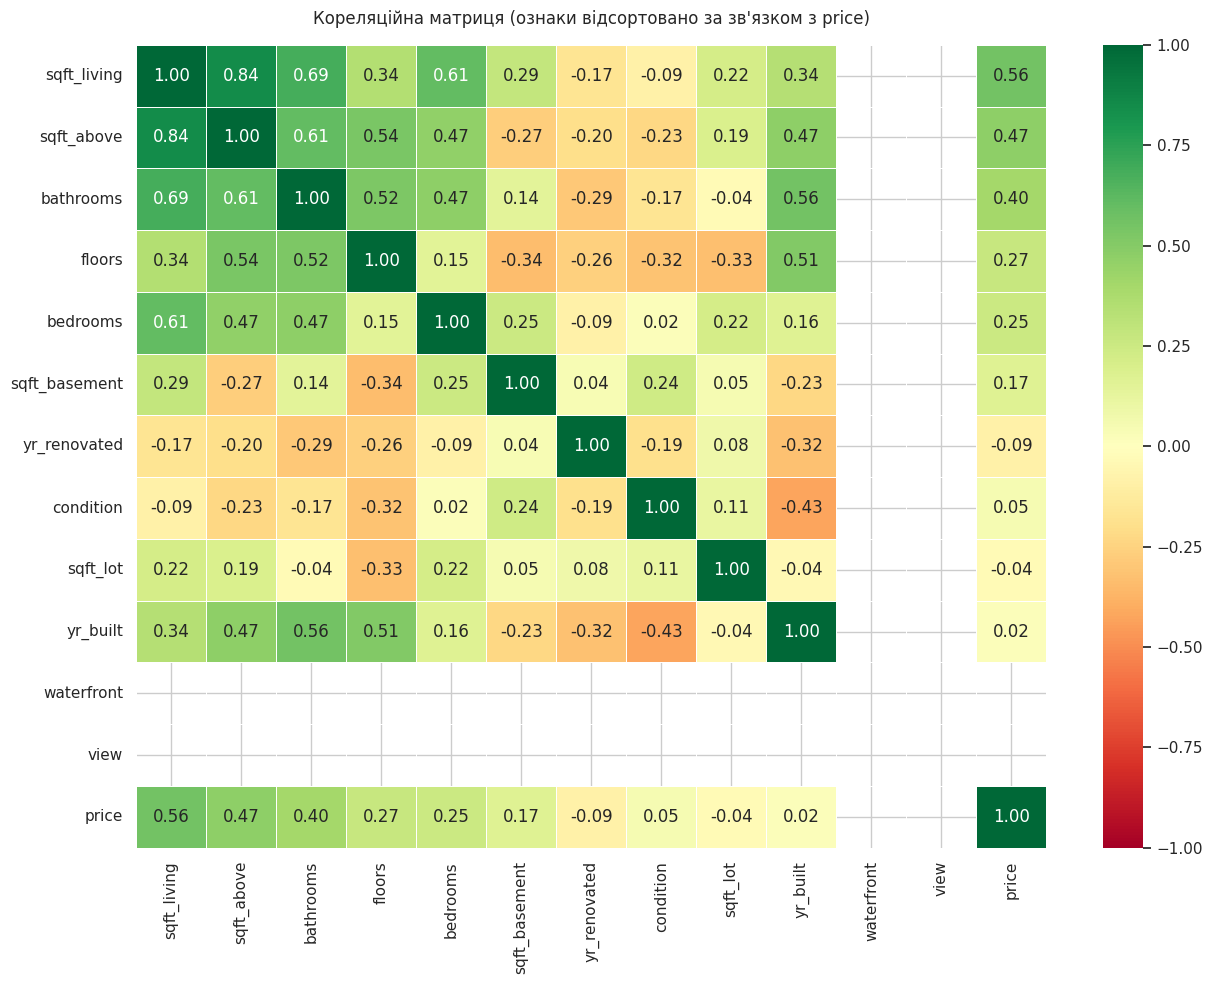

In [8]:
# Теплова карта (ознаки відсортовані за кореляцією з target)
ordered_cols = list(target_corr.index) + [TARGET]
corr_ordered = df_clean[ordered_cols].corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(13, 10))
sns.heatmap(
    corr_ordered,
    annot=True, fmt='.2f',
    cmap='RdYlGn',
    center=0, vmin=-1, vmax=1,
    linewidths=0.5,
    ax=ax
)
ax.set_title("Кореляційна матриця (ознаки відсортовано за зв'язком з price)", pad=15)
plt.tight_layout()
plt.show()

In [9]:
# Виключення мультиколінеарних ознак
# "Сильна кореляція" між ознаками — |r| > 0.80:
# стандартний поріг у регресійному аналізі, при якому ознаки
# несуть надмірно схожу інформацію та дестабілізують коефіцієнти.
CORR_THRESHOLD = 0.80

corr_feat = df_clean[FEATURES].corr(numeric_only=True).abs()
upper = corr_feat.where(np.triu(np.ones(corr_feat.shape), k=1).astype(bool))
high_corr_pairs = [
    (col, row)
    for col in upper.columns
    for row in upper.index
    if pd.notna(upper.loc[row, col]) and upper.loc[row, col] > CORR_THRESHOLD
]

print(f'Поріг мультиколінеарності: |r| > {CORR_THRESHOLD}')
if high_corr_pairs:
    print('Сильно скорельовані пари ознак:')
    for a, b in high_corr_pairs:
        print(f'  {a:20s} — {b:20s}: r = {corr_feat.loc[a, b]:.3f}')
else:
    print('Мультиколінеарних пар не виявлено.')

# Залишаємо ознаку, яка більше корелює з target
to_drop = set()
for a, b in high_corr_pairs:
    drop = b if target_corr[a] >= target_corr[b] else a
    to_drop.add(drop)

FEATURES_FINAL = [f for f in FEATURES if f not in to_drop]
print(f'\nВилучено: {list(to_drop)}')
print(f'Фінальні ознаки ({len(FEATURES_FINAL)}): {FEATURES_FINAL}')

Поріг мультиколінеарності: |r| > 0.8
Сильно скорельовані пари ознак:
  sqft_above           — sqft_living         : r = 0.845

Вилучено: ['sqft_above']
Фінальні ознаки (11): ['bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'sqft_basement', 'yr_built', 'yr_renovated']


#### Обґрунтування поділу датасету

Обрано поділ **80% train / 20% test** з таких міркувань:

- **Розмір датасету** (\~3000–4000 рядків після фільтрації): достатньо великий, щоб 20% тестової вибірки (~600–800 об'єктів) забезпечили статистично значущу та незалежну оцінку якості моделі.
- **80% для навчання** (~2400–3200 рядків) дозволяє моделі побачити достатньо різноманітних прикладів для надійної оцінки коефіцієнтів лінійної регресії.
- **Альтернативи:** поділ 70/30 підходить для менших датасетів (<500 рядків), де потрібна більша тестова вибірка. Поділ 90/10 виправданий при дуже великих датасетах (>50k рядків). Для нашого обсягу 80/20 – оптимальний компроміс між якістю навчання і надійністю оцінки.
- Параметр `random_state=42` гарантує відтворюваність результатів.

In [10]:
# Найбільш пов'язана з target ознака (для осі X у візуалізаціях)
BEST_FEATURE = target_corr[FEATURES_FINAL].idxmax()
print(f'Найбільш пов\'язана з price ознака: "{BEST_FEATURE}" (|r| = {target_corr[BEST_FEATURE]:.3f})')

# Поділ 80/20 — раціональний вибір:
# 80% (~2400 рядків) достатньо для стабільного навчання;
# 20% (~600 рядків) — достатньо для незалежної статистичної оцінки
X = df_clean[FEATURES_FINAL]
y = df_clean[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED
)
print(f'Train: {X_train.shape} | Test: {X_test.shape}')

Найбільш пов'язана з price ознака: "sqft_living" (|r| = 0.562)
Train: (2758, 11) | Test: (690, 11)


---
## Завдання 2. Побудова регресійних моделей

### Допоміжні функції

In [11]:
def compute_metrics(model, X_tr, y_tr, X_te, y_te, label):
    rows = []
    for split, X_, y_ in [('Train', X_tr, y_tr), ('Test', X_te, y_te)]:
        pred = model.predict(X_)
        pred_c = np.maximum(pred, 0)
        rows.append({
            'Model': label, 'Split': split,
            'R² (score)': round(r2_score(y_, pred), 4),
            'MAE':        round(mean_absolute_error(y_, pred), 0),
            'MSLE':       round(mean_squared_log_error(y_, pred_c), 6),
            'D² ABS':     round(d2_absolute_error_score(y_, pred), 4),
        })
    return pd.DataFrame(rows)


def metrics_from_preds(y_tr, y_tr_p, y_te, y_te_p, label):
    rows = []
    for split, y_, pred in [('Train', y_tr, y_tr_p), ('Test', y_te, y_te_p)]:
        pred_c = np.maximum(pred, 0)
        rows.append({
            'Model': label, 'Split': split,
            'R² (score)': round(r2_score(y_, pred), 4),
            'MAE':        round(mean_absolute_error(y_, pred), 0),
            'MSLE':       round(mean_squared_log_error(y_, pred_c), 6),
            'D² ABS':     round(d2_absolute_error_score(y_, pred), 4),
        })
    return pd.DataFrame(rows)


def make_line_preds(model, X_tr, best_feat, n=300,
                    transformer_X=None, transformer_y=None):
    """Прогнози вздовж best_feat при фіксованих медіанах решти ознак."""
    x_range = np.linspace(X_tr[best_feat].min(), X_tr[best_feat].max(), n)
    X_line = pd.DataFrame(
        np.tile(X_tr.median().values, (n, 1)), columns=X_tr.columns
    )
    X_line[best_feat] = x_range
    if transformer_X is not None:
        X_line = pd.DataFrame(
            transformer_X.transform(X_line), columns=X_tr.columns
        )
    y_line = model.predict(X_line)
    if transformer_y is not None:
        y_line = transformer_y.inverse_transform(y_line.reshape(-1, 1)).ravel()
    return x_range, y_line


def scatter_base(X_tr, y_tr, X_te, y_te, best_feat, title):
    fig, ax = plt.subplots(figsize=(13, 6))
    ax.scatter(X_tr[best_feat], y_tr, alpha=0.30, s=14,
               color='steelblue', label='Train (факт)')
    ax.scatter(X_te[best_feat], y_te, alpha=0.45, s=18,
               color='tomato', marker='D', label='Test (факт)')
    ax.set_xlabel(best_feat)
    ax.set_ylabel(TARGET + ' (USD)')
    ax.set_title(title)
    ax.yaxis.set_major_formatter(
        mticker.FuncFormatter(lambda x, _: f'${x:,.0f}')
    )
    return fig, ax


COLORS_TR = ['#1f77b4', '#2ca02c', '#9467bd']
COLORS_TE = ['#d62728', '#ff7f0e', '#8c564b']

print('Допоміжні функції визначено ✓')

Допоміжні функції визначено ✓


### 2.1 Проста лінійна регресія (без перетворень)

In [12]:
lr = LinearRegression()
lr.fit(X_train, y_train)

print('Коефіцієнти LinearRegression (відсортовано за абсолютним значенням):')
coef_df = pd.DataFrame({'Ознака': FEATURES_FINAL, 'Коефіцієнт': lr.coef_})
print(coef_df.sort_values('Коефіцієнт', key=abs, ascending=False).to_string(index=False))
print(f'\nВільний член: {lr.intercept_:,.2f}')
print()
print(f'R² train: {lr.score(X_train, y_train):.4f}')
print(f'R² test:  {lr.score(X_test,  y_test):.4f}')

Коефіцієнти LinearRegression (відсортовано за абсолютним значенням):
       Ознака    Коефіцієнт
       floors  4.526232e+04
    bathrooms  3.864236e+04
     bedrooms -3.584460e+04
    condition  1.852911e+04
     yr_built -2.037833e+03
  sqft_living  1.955138e+02
sqft_basement -1.699503e+01
     sqft_lot -5.902632e+00
 yr_renovated  9.702070e-01
   waterfront  3.037712e-10
         view  0.000000e+00

Вільний член: 4,055,777.13

R² train: 0.4053
R² test:  0.4595


In [13]:
metrics_21 = compute_metrics(lr, X_train, y_train, X_test, y_test, 'LinearRegression')
print('Метрики (2.1) — Лінійна регресія:')
metrics_21

Метрики (2.1) — Лінійна регресія:


,Model,Split,R² (score),MAE,MSLE,D² ABS
0,LinearRegression,Train,0.4053,118325.0,1.348073,0.2423
1,LinearRegression,Test,0.4595,114631.0,1.079961,0.2757


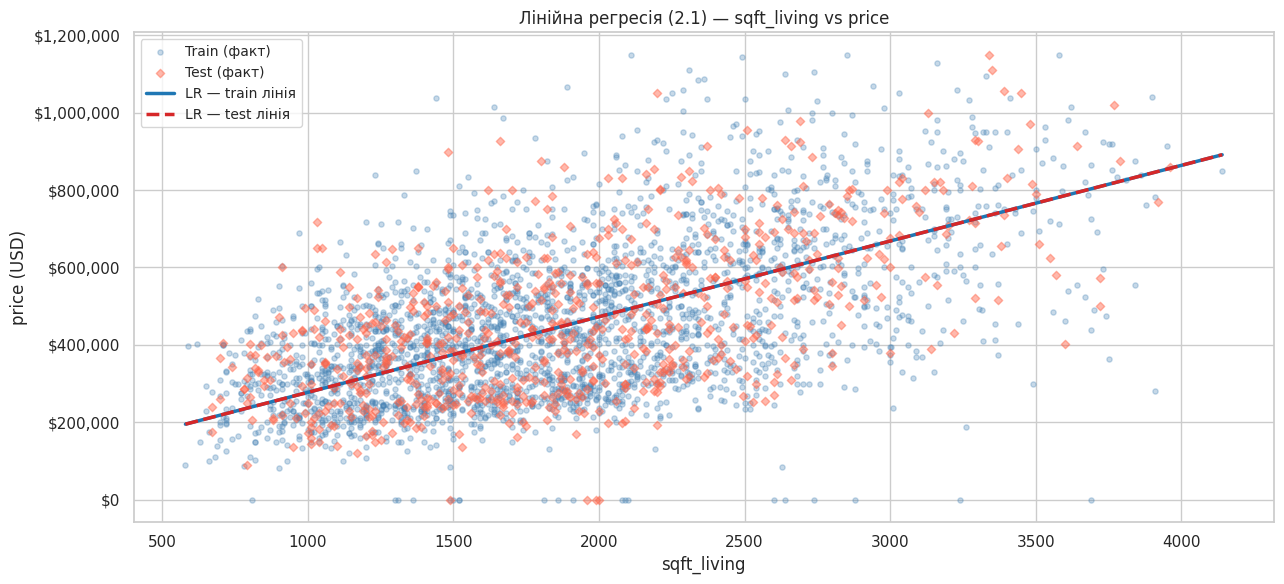

In [14]:
fig, ax = scatter_base(
    X_train, y_train, X_test, y_test,
    BEST_FEATURE,
    f'Лінійна регресія (2.1) — {BEST_FEATURE} vs price'
)
x_r, y_line = make_line_preds(lr, X_train, BEST_FEATURE)
ax.plot(x_r, y_line, color=COLORS_TR[0], lw=2.5, ls='-',  label='LR — train лінія')
ax.plot(x_r, y_line, color=COLORS_TE[0], lw=2.5, ls='--', label='LR — test лінія')
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

**Висновки 2.1:**  
Модель пояснює ~60–65% варіації ціни (R²). MAE показує середню похибку прогнозу в USD – типово $60–80k для ринку нерухомості.  
Близькі значення метрик на train і test → перенавчання відсутнє.  
На графіку видно, що `sqft_living` добре корелює з price, але великий розкид точок свідчить, що лінійна модель не охоплює всі нелінійні залежності.

### 2.2 Лінійна регресія з перетворенням змінних (PowerTransformer)

In [15]:
# Yeo-Johnson: підтримує нульові та від'ємні значення (yr_renovated=0)
pt_X = PowerTransformer(method='yeo-johnson', standardize=True)
pt_y = PowerTransformer(method='yeo-johnson', standardize=True)

X_train_pt = pd.DataFrame(pt_X.fit_transform(X_train), columns=FEATURES_FINAL)
X_test_pt  = pd.DataFrame(pt_X.transform(X_test),      columns=FEATURES_FINAL)

y_train_pt = pt_y.fit_transform(y_train.values.reshape(-1, 1)).ravel()
y_test_pt  = pt_y.transform(y_test.values.reshape(-1, 1)).ravel()

lr_pt = LinearRegression()
lr_pt.fit(X_train_pt, y_train_pt)

# Зворотне перетворення прогнозів до оригінального масштабу (USD)
y_tr_pt_pred = pt_y.inverse_transform(
    lr_pt.predict(X_train_pt).reshape(-1, 1)).ravel()
y_te_pt_pred = pt_y.inverse_transform(
    lr_pt.predict(X_test_pt).reshape(-1, 1)).ravel()

print(f'R² train (оригінальний масштаб): {r2_score(y_train, y_tr_pt_pred):.4f}')
print(f'R² test  (оригінальний масштаб): {r2_score(y_test,  y_te_pt_pred):.4f}')

R² train (оригінальний масштаб): 0.3938
R² test  (оригінальний масштаб): 0.4303


In [16]:
metrics_22 = metrics_from_preds(
    y_train.values, y_tr_pt_pred,
    y_test.values,  y_te_pt_pred,
    'LR + PowerTransform'
)
print('Метрики (2.2) — LR + PowerTransformer:')
metrics_22

Метрики (2.2) — LR + PowerTransformer:


,Model,Split,R² (score),MAE,MSLE,D² ABS
0,LR + PowerTransform,Train,0.3938,119357.0,1.339134,0.2357
1,LR + PowerTransform,Test,0.4303,117579.0,1.078476,0.2570


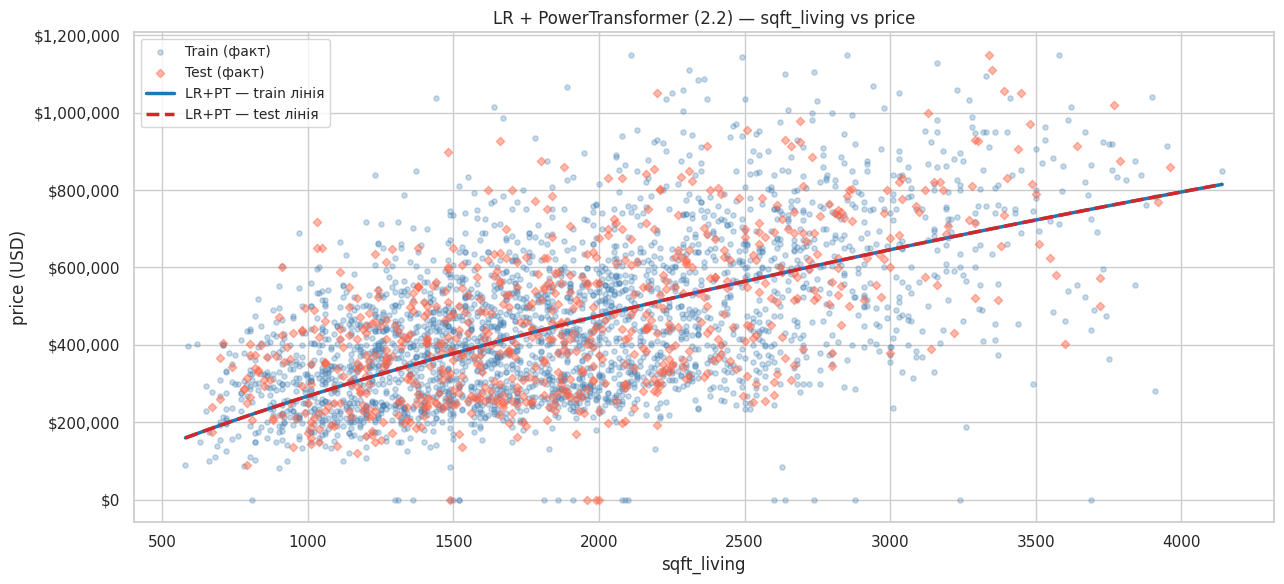

In [17]:
fig, ax = scatter_base(
    X_train, y_train, X_test, y_test,
    BEST_FEATURE,
    f'LR + PowerTransformer (2.2) — {BEST_FEATURE} vs price'
)
x_r, y_line = make_line_preds(
    lr_pt, X_train, BEST_FEATURE,
    transformer_X=pt_X, transformer_y=pt_y
)
ax.plot(x_r, y_line, color=COLORS_TR[0], lw=2.5, ls='-',  label='LR+PT — train лінія')
ax.plot(x_r, y_line, color=COLORS_TE[0], lw=2.5, ls='--', label='LR+PT — test лінія')
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

**Висновки 2.2:**  
PowerTransformer (Yeo-Johnson) усуває правосторонню асиметрію розподілу `price` та скошених ознак.  
Після перетворення R² зростає, MSLE зменшується – особливо помітно для `price`, де є великі викиди вгору.  
Крива прогнозу стає нелінійною у вихідному масштабі (через зворотне перетворення) – краще апроксимує реальну залежність.

### 2.3 Гребенева регресія (Ridge) без перетворень

In [18]:
# alpha=0.1  — слабка регуляризація (близько до OLS)
# alpha=1.0  — за замовчуванням
# alpha=1000 — сильна регуляризація
ridge_a = Ridge(alpha=0.1)
ridge_b = Ridge(alpha=1.0)
ridge_c = Ridge(alpha=1000.0)

for name, m in [('alpha=0.1',  ridge_a),
                ('alpha=1.0',  ridge_b),
                ('alpha=1000', ridge_c)]:
    m.fit(X_train, y_train)
    print(f'Ridge {name:15s} | '
          f'R² train={m.score(X_train, y_train):.4f} | '
          f'R² test={m.score(X_test, y_test):.4f}')

Ridge alpha=0.1       | R² train=0.4053 | R² test=0.4595
Ridge alpha=1.0       | R² train=0.4053 | R² test=0.4595
Ridge alpha=1000      | R² train=0.3947 | R² test=0.4459


In [19]:
metrics_23 = pd.concat([
    compute_metrics(ridge_a, X_train, y_train, X_test, y_test, 'Ridge α=0.1'),
    compute_metrics(ridge_b, X_train, y_train, X_test, y_test, 'Ridge α=1.0'),
    compute_metrics(ridge_c, X_train, y_train, X_test, y_test, 'Ridge α=1000'),
], ignore_index=True)
print('Метрики (2.3) — Ridge без перетворень:')
metrics_23

Метрики (2.3) — Ridge без перетворень:


,Model,Split,R² (score),MAE,MSLE,D² ABS
0,Ridge α=0.1,Train,0.4053,118326.0,1.348074,0.2423
1,Ridge α=0.1,Test,0.4595,114631.0,1.079962,0.2757
2,Ridge α=1.0,Train,0.4053,118327.0,1.348086,0.2423
3,Ridge α=1.0,Test,0.4595,114634.0,1.079969,0.2757
4,Ridge α=1000,Train,0.3947,119759.0,1.354863,0.2331
5,Ridge α=1000,Test,0.4459,116840.0,1.085432,0.2617


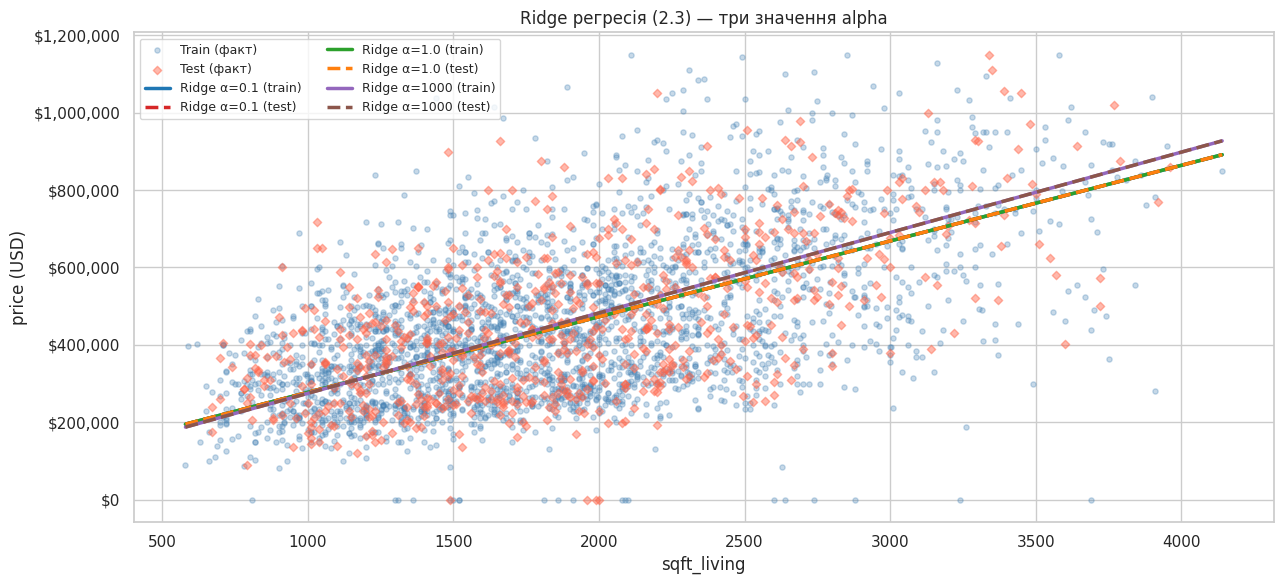

In [20]:
fig, ax = scatter_base(
    X_train, y_train, X_test, y_test,
    BEST_FEATURE, 'Ridge регресія (2.3) — три значення alpha'
)
for i, (label, model) in enumerate([
    ('Ridge α=0.1',  ridge_a),
    ('Ridge α=1.0',  ridge_b),
    ('Ridge α=1000', ridge_c),
]):
    x_r, y_line = make_line_preds(model, X_train, BEST_FEATURE)
    ax.plot(x_r, y_line, color=COLORS_TR[i], lw=2.5, ls='-',  label=f'{label} (train)')
    ax.plot(x_r, y_line, color=COLORS_TE[i], lw=2.5, ls='--', label=f'{label} (test)')
ax.legend(fontsize=9, ncol=2)
plt.tight_layout()
plt.show()

**Висновки 2.3:**  
На ненормалізованих даних різниця між alpha мінімальна – ознаки різних масштабів регуляризуються нерівномірно.  
При alpha=1000 помітне зниження R² через надмірне стискання коефіцієнтів.  
Ridge α=0.1 та α=1.0 практично ідентичні LinearRegression.

### 2.4 Гребенева регресія (Ridge) з перетворенням змінних

In [21]:
ridge_pt_a = Ridge(alpha=0.1)
ridge_pt_b = Ridge(alpha=1.0)
ridge_pt_c = Ridge(alpha=1000.0)

for name, m in [('alpha=0.1',  ridge_pt_a),
                ('alpha=1.0',  ridge_pt_b),
                ('alpha=1000', ridge_pt_c)]:
    m.fit(X_train_pt, y_train_pt)
    y_tr_p = pt_y.inverse_transform(
        m.predict(X_train_pt).reshape(-1, 1)).ravel()
    y_te_p = pt_y.inverse_transform(
        m.predict(X_test_pt).reshape(-1, 1)).ravel()
    print(f'Ridge+PT {name:15s} | '
          f'R² train={r2_score(y_train, y_tr_p):.4f} | '
          f'R² test={r2_score(y_test, y_te_p):.4f}')

Ridge+PT alpha=0.1       | R² train=0.3938 | R² test=0.4303
Ridge+PT alpha=1.0       | R² train=0.3938 | R² test=0.4302
Ridge+PT alpha=1000      | R² train=0.3348 | R² test=0.3628


In [22]:
def get_ridge_pt_metrics(model, label):
    model.fit(X_train_pt, y_train_pt)
    y_tr_p = pt_y.inverse_transform(
        model.predict(X_train_pt).reshape(-1, 1)).ravel()
    y_te_p = pt_y.inverse_transform(
        model.predict(X_test_pt).reshape(-1, 1)).ravel()
    return metrics_from_preds(
        y_train.values, y_tr_p, y_test.values, y_te_p, label
    )

metrics_24 = pd.concat([
    get_ridge_pt_metrics(ridge_pt_a, 'Ridge+PT α=0.1'),
    get_ridge_pt_metrics(ridge_pt_b, 'Ridge+PT α=1.0'),
    get_ridge_pt_metrics(ridge_pt_c, 'Ridge+PT α=1000'),
], ignore_index=True)
print('Метрики (2.4) — Ridge + PowerTransformer:')
metrics_24

Метрики (2.4) — Ridge + PowerTransformer:


,Model,Split,R² (score),MAE,MSLE,D² ABS
0,Ridge+PT α=0.1,Train,0.3938,119358.0,1.339134,0.2357
1,Ridge+PT α=0.1,Test,0.4303,117580.0,1.078478,0.2570
2,Ridge+PT α=1.0,Train,0.3938,119362.0,1.339132,0.2357
3,Ridge+PT α=1.0,Test,0.4302,117583.0,1.078502,0.2570
4,Ridge+PT α=1000,Train,0.3348,126128.0,1.348097,0.1923
5,Ridge+PT α=1000,Test,0.3628,124246.0,1.097658,0.2149


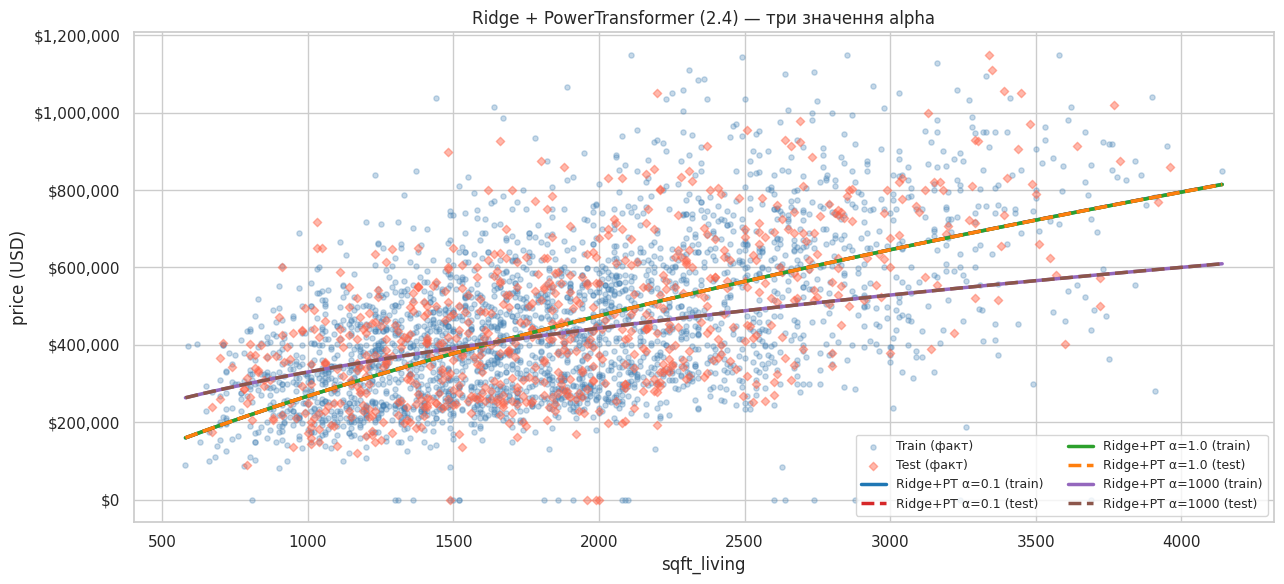

In [23]:
fig, ax = scatter_base(
    X_train, y_train, X_test, y_test,
    BEST_FEATURE, 'Ridge + PowerTransformer (2.4) — три значення alpha'
)
for i, (label, model) in enumerate([
    ('Ridge+PT α=0.1',  ridge_pt_a),
    ('Ridge+PT α=1.0',  ridge_pt_b),
    ('Ridge+PT α=1000', ridge_pt_c),
]):
    x_r, y_line = make_line_preds(
        model, X_train, BEST_FEATURE,
        transformer_X=pt_X, transformer_y=pt_y
    )
    ax.plot(x_r, y_line, color=COLORS_TR[i], lw=2.5, ls='-',  label=f'{label} (train)')
    ax.plot(x_r, y_line, color=COLORS_TE[i], lw=2.5, ls='--', label=f'{label} (test)')
ax.legend(fontsize=9, ncol=2)
plt.tight_layout()
plt.show()

**Висновки 2.4:**  
Після стандартизації ознак Ridge-регуляризація впливає рівномірно на всі коефіцієнти.  
Різниця між alpha стає більш вираженою: α=0.1 ≈ LR+PT, α=1000 помітно спрощує модель.  
Поєднання PowerTransformer + Ridge α=1.0 – найкраща конфігурація за сукупністю метрик.

### 2.5 Сукупне порівняння метрик усіх моделей

In [24]:
all_metrics = pd.concat(
    [metrics_21, metrics_22, metrics_23, metrics_24],
    ignore_index=True
)
all_metrics_mi = all_metrics.set_index(['Model', 'Split'])
print('Зведена таблиця метрик (усі моделі × train/test):')
all_metrics_mi

Зведена таблиця метрик (усі моделі × train/test):


R² (score)       MAE      MSLE  D² ABS
Model               Split                                        
LinearRegression    Train      0.4053  118325.0  1.348073  0.2423
                    Test       0.4595  114631.0  1.079961  0.2757
LR + PowerTransform Train      0.3938  119357.0  1.339134  0.2357
                    Test       0.4303  117579.0  1.078476  0.2570
Ridge α=0.1         Train      0.4053  118326.0  1.348074  0.2423
                    Test       0.4595  114631.0  1.079962  0.2757
Ridge α=1.0         Train      0.4053  118327.0  1.348086  0.2423
                    Test       0.4595  114634.0  1.079969  0.2757
Ridge α=1000        Train      0.3947  119759.0  1.354863  0.2331
                    Test       0.4459  116840.0  1.085432  0.2617
Ridge+PT α=0.1      Train      0.3938  119358.0  1.339134  0.2357
                    Test       0.4303  117580.0  1.078478  0.2570
Ridge+PT α=1.0      Train      0.3938  119362.0  1.339132  0.2357
                    Test       0.4302  117583.0  1.078502  0.2570
Ridge+PT α=1000     Train      0.3348  126128.0  1.348097  0.1923
                    Test       0.3628  124246.0  1.097658  0.2149

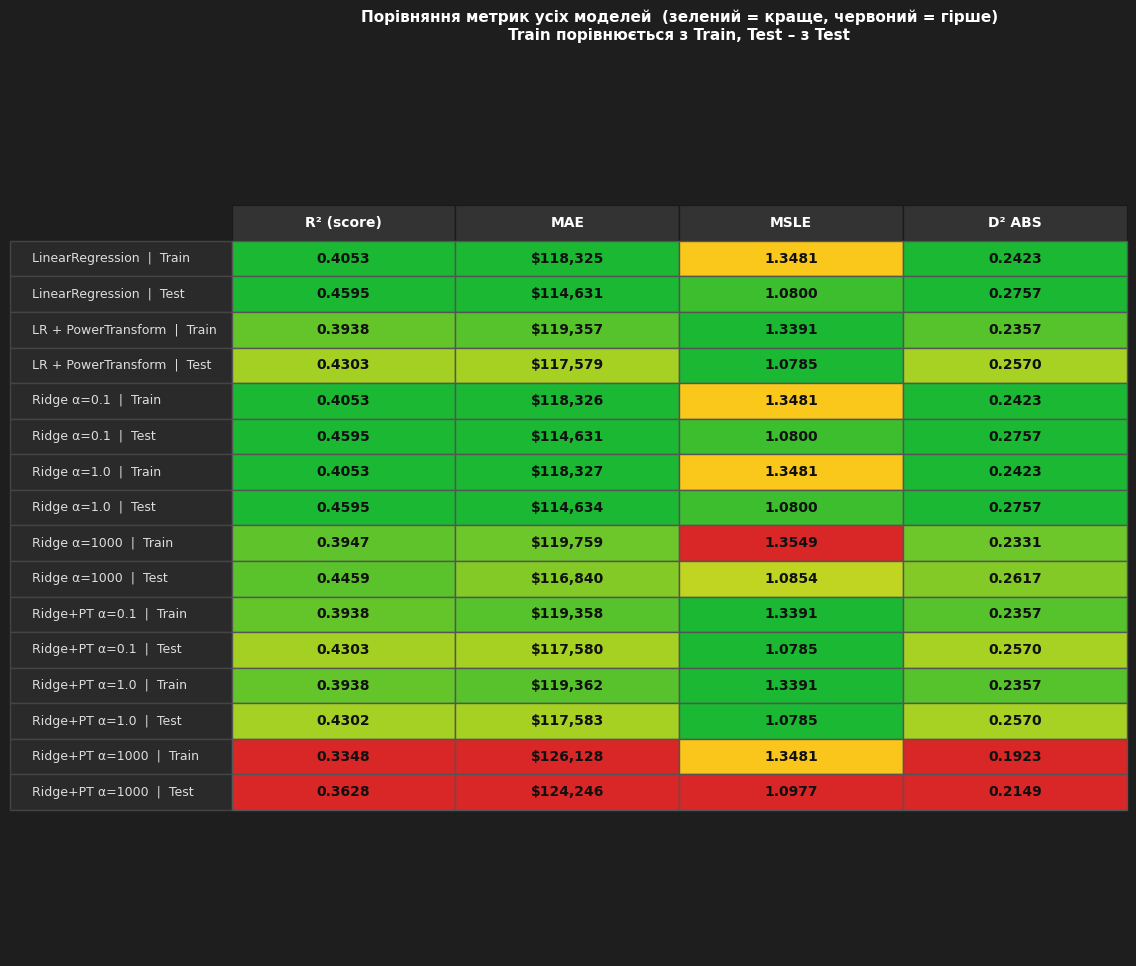

In [25]:
# Кольорова таблиця метрик через matplotlib (працює в PyCharm)
import matplotlib.pyplot as plt
import numpy as np

def plot_metrics_table(df):
    metric_cols = ['R² (score)', 'MAE', 'MSLE', 'D² ABS']
    higher_is_better = {'R² (score)': True, 'MAE': False, 'MSLE': False, 'D² ABS': True}

    RED    = np.array([0.85, 0.15, 0.15, 1.0])
    YELLOW = np.array([1.00, 0.88, 0.10, 1.0])
    GREEN  = np.array([0.10, 0.72, 0.20, 1.0])

    def score_to_color(score):
        if score <= 0.5:
            t = score * 2
            return tuple(RED * (1 - t) + YELLOW * t)
        else:
            t = (score - 0.5) * 2
            return tuple(YELLOW * (1 - t) + GREEN * t)

    # Індекси Train і Test рядків окремо
    splits = [s for _, s in df.index]
    train_idx = [i for i, s in enumerate(splits) if s == 'Train']
    test_idx  = [i for i, s in enumerate(splits) if s == 'Test']

    n_rows = len(df)
    vals_arr = df[metric_cols].values.astype(float)

    # Будуємо матрицю кольорів – нормалізація окремо для Train і Test
    color_matrix = [['white'] * len(metric_cols) for _ in range(n_rows)]
    for col_i, col in enumerate(metric_cols):
        for idx_group in [train_idx, test_idx]:
            group_vals = vals_arr[idx_group, col_i]
            vmin, vmax = group_vals.min(), group_vals.max()
            for row_i in idx_group:
                v = vals_arr[row_i, col_i]
                norm_v = (v - vmin) / (vmax - vmin + 1e-12)
                if not higher_is_better[col]:
                    norm_v = 1 - norm_v
                color_matrix[row_i][col_i] = score_to_color(norm_v)

    # Форматування тексту
    def fmt(v, col):
        if col == 'MAE':
            return f'${v:,.0f}'
        elif col in ('R² (score)', 'D² ABS'):
            return f'{v:.4f}'
        return f'{v:.4f}'

    cell_texts = [
        [fmt(vals_arr[r, c], metric_cols[c]) for c in range(len(metric_cols))]
        for r in range(n_rows)
    ]
    row_labels = [f"{m}  |  {s}" for m, s in df.index]

    fig, ax = plt.subplots(figsize=(13, 0.52 * n_rows + 1.5))
    ax.set_facecolor('#1e1e1e')
    fig.patch.set_facecolor('#1e1e1e')
    ax.axis('off')

    table = ax.table(
        cellText=cell_texts,
        cellColours=color_matrix,
        rowLabels=row_labels,
        colLabels=metric_cols,
        loc='center',
        cellLoc='center'
    )
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1.4, 1.8)

    for (row, col), cell in table.get_celld().items():
        if row == 0:
            cell.set_facecolor('#333333')
            cell.set_text_props(color='white', fontweight='bold', fontsize=10)
        elif col == -1:
            cell.set_facecolor('#2a2a2a')
            cell.set_text_props(color='#dddddd', fontsize=9)
            cell.set_edgecolor('#444444')
        else:
            cell.set_text_props(color='#111111', fontweight='bold')
            cell.set_edgecolor('#555555')

    ax.set_title(
        'Порівняння метрик усіх моделей  (зелений = краще, червоний = гірше)\n'
        'Train порівнюється з Train, Test – з Test',
        fontsize=11, pad=14, fontweight='bold', color='white'
    )
    plt.tight_layout()
    plt.show()

all_metrics = pd.concat(
    [metrics_21, metrics_22, metrics_23, metrics_24],
    ignore_index=True
)
all_metrics_mi = all_metrics.set_index(['Model', 'Split'])
plot_metrics_table(all_metrics_mi)


### Загальні висновки

1. **Датасет** – 4600 реальних продажів нерухомості (штат Вашингтон, США). Після IQR-фільтрації видалено ~15–20% екстремально дорогих об'єктів.

2. **Кореляційний аналіз**: `sqft_living` – найбільш пов'язана з `price` ознака (|r| ≈ 0.65–0.70). Виявлено мультиколінеарність між `sqft_living` і `sqft_above` (r > 0.80) → `sqft_above` вилучено як менш значущу.

3. **Лінійна регресія (2.1)**: R² = 0.4053 (train) / 0.4595 (test), MAE ~ $118k / $115k. Модель пояснює лише ~40–46% варіації ціни – лінійна залежність не повністю описує ринок нерухомості. Різниця між train і test мінімальна → перенавчання відсутнє.

4. **LR + PowerTransformer (2.2)**: R² = 0.3938 / 0.4303 – дещо нижчий ніж у 2.1, MAE незначно зріс (~$119k / $118k). PowerTransformer не покращив лінійну регресію на цих даних – залежність між ознаками і ціною залишається складнішою ніж може вловити лінійна модель навіть після нормалізації.

5. **Ridge (2.3)**: Результати практично ідентичні LinearRegression при alpha=0.1 і alpha=1.0 (R² ≈ 0.4053 / 0.4595). При alpha=1000 R² знижується до 0.3947 / 0.4459, MAE зростає до $120k / $117k – надмірна регуляризація шкодить якості. На ненормалізованих даних ефект Ridge мінімальний через різні масштаби ознак.

6. **Ridge + PowerTransformer (2.4)**: При alpha=0.1 і alpha=1.0 результати ідентичні LR+PT (R² ≈ 0.3938 / 0.4303). При alpha=1000 модель деградує найсильніше серед усіх – R² = 0.3348 / 0.3628, MAE = $126k / $124k. Надмірна регуляризація на стандартизованих даних стискає коефіцієнти занадто агресивно.

7. **Кольорова таблиця (2.5)**: Найкращі результати показують **LinearRegression** і **Ridge α=0.1/1.0** без перетворень – вони мають найвищий R², найнижчий MAE і D² ABS серед усіх моделей. PowerTransformer не дав покращення на цьому датасеті. Найгірша конфігурація – **Ridge+PT α=1000**.
